In this notebook, we train our DualEncoder-FNO model.

### 1. Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from neuralop import LpLoss, H1Loss

from rve_analyzer import RVEDataset, DualEncoderFNO, Trainer

### 2. Configuration

In [2]:
from types import SimpleNamespace

cfg = SimpleNamespace(**{})

In [3]:
cfg.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {cfg.device}")

Device: cuda


In [4]:
cfg.h5_path = Path("../master_data/rve_run2.h5")
cfg.batch_size = 64
cfg.num_workers = 0
cfg.seed = 42
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)

### 3. Datasets & DataLoader

In [5]:
cfg.in_memory = True
cfg.fraction = 1.00

train_dataset = RVEDataset(cfg.h5_path, split='train', in_memory=cfg.in_memory, fraction=cfg.fraction)
val_dataset   = RVEDataset(cfg.h5_path, split='val', in_memory=cfg.in_memory, fraction=cfg.fraction)
test_dataset  = RVEDataset(cfg.h5_path, split='test', in_memory=cfg.in_memory, fraction=cfg.fraction)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Get dimensions
sample_xl, sample_xg, sample_y = train_dataset[0]
in_channels = sample_xl.shape[0]      # phase + nstatev + ...
out_channels = sample_y.shape[0]
n_macro = sample_xg.shape[0]

print(f"in_channels={in_channels}, out_channels={out_channels}, n_macro={n_macro}")


Loading 100% of 'train' split into RAM. This may take a moment...
Loading 100% of 'val' split into RAM. This may take a moment...
Loading 100% of 'test' split into RAM. This may take a moment...
Train: 60000 | Val: 20000 | Test: 20000
in_channels=1, out_channels=3, n_macro=3


In [ ]:
def save_normalizers(dataset, save_dir="../checkpoints", filename="rve_fno_normalizers.pth"):
    """
    Save normalizer objects
    """

    path = Path(save_dir)
    path.mkdir(exist_ok=True, parents=True)
    
    normalizers = {
        'x_normalizer': getattr(dataset, 'x_normalizer', None),
        'global_normalizer': getattr(dataset, 'global_normalizer', None),
        'y_normalizer': getattr(dataset, 'y_normalizer', None)
    }
    
    save_path = path / filename
    torch.save(normalizers, save_path)
    
    print(f"Normalizers save in: {save_path}")

save_normalizers(train_dataset, filename = "rve2_fno_normalizers.pth")

Normalizers save in: checkpoints\rve2_fno_normalizers.pth


In [7]:
def check_normalization_per_channel(dataset, in_channels, n_macro, out_channels, batch_size=32):
    """
    """
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    # Initialize zero tensors to accumulate sum and squared sum per channel
    xl_sum = torch.zeros(in_channels)
    xl_sq_sum = torch.zeros(in_channels)
    xl_count = 0
    
    xg_sum = torch.zeros(n_macro)
    xg_sq_sum = torch.zeros(n_macro)
    xg_count = 0
    
    y_sum = torch.zeros(out_channels)
    y_sq_sum = torch.zeros(out_channels)
    y_count = 0

    print("Computing mean and standard deviation per channel...")

    for xl, xg, y in loader:
        B = xl.size(0)  # Current batch size
        
        # Process x_local: [B, C_in, H, W] -> Flatten spatial dims to [B, C_in, N]
        xl_flat = xl.view(B, in_channels, -1)
        # Sum along the batch dimension (0) and spatial pixels (2), preserving channels (1)
        xl_sum += xl_flat.sum(dim=(0, 2))
        xl_sq_sum += (xl_flat ** 2).sum(dim=(0, 2))
        # Total elements per channel: Batch size * Number of pixels
        xl_count += B * xl_flat.size(2)
        
        # Process x_global: Assuming shape [B, n_macro] (no spatial dimensions)
        xg_sum += xg.sum(dim=0)
        xg_sq_sum += (xg ** 2).sum(dim=0)
        xg_count += B
        
        # Process y_local: [B, C_out, H, W] -> Flatten to [B, C_out, N]
        y_flat = y.view(B, out_channels, -1)
        y_sum += y_flat.sum(dim=(0, 2))
        y_sq_sum += (y_flat ** 2).sum(dim=(0, 2))
        y_count += B * y_flat.size(2)

    # Helper function to compute the final mean and std per channel
    def get_channel_stats(c_sum, c_sq_sum, count):
        mean = c_sum / count
        # Variance = E[X^2] - (E[X])^2
        variance = (c_sq_sum / count) - (mean ** 2)
        # Clamp to 0 to avoid negative variances due to floating-point precision errors
        variance = torch.clamp(variance, min=0.0)
        std = torch.sqrt(variance)
        return mean, std

    # Compute final statistics
    xl_mean, xl_std = get_channel_stats(xl_sum, xl_sq_sum, xl_count)
    xg_mean, xg_std = get_channel_stats(xg_sum, xg_sq_sum, xg_count)
    y_mean, y_std = get_channel_stats(y_sum, y_sq_sum, y_count)

    # Print the final report
    print("\n" + "="*50)
    print("NORMALIZATION REPORT")
    print("="*50)

    def print_stats(name, mean_tensor, std_tensor, tol=0.05):
        print(f"\n--- {name} ---")
        for i, (m, s) in enumerate(zip(mean_tensor, std_tensor)):
            # Visual warning if a channel deviates from Mean=0 and Std=1
            status = "✅" if (abs(m.item()) < tol and abs(s.item() - 1.0) < tol) else "⚠️"
            print(f"Channel {i}: Mean = {m.item():7.4f} | Std = {s.item():7.4f}  {status}")

    print_stats("x_local (in_channels)", xl_mean, xl_std)
    print_stats("x_global (n_macro)", xg_mean, xg_std)
    print_stats("y_local (out_channels)", y_mean, y_std)
    print("\n" + "="*50)

# Execute the check on the training dataset
check_normalization_per_channel(train_dataset, in_channels, n_macro, out_channels, batch_size=cfg.batch_size )

Computing mean and standard deviation per channel...

NORMALIZATION REPORT

--- x_local (in_channels) ---
Channel 0: Mean = -0.0000 | Std =  1.0000  ✅

--- x_global (n_macro) ---
Channel 0: Mean =  0.0000 | Std =  1.0000  ✅
Channel 1: Mean = -0.0000 | Std =  1.0000  ✅
Channel 2: Mean = -0.0000 | Std =  1.0000  ✅

--- y_local (out_channels) ---
Channel 0: Mean = -0.0000 | Std =  1.0000  ✅
Channel 1: Mean =  0.0000 | Std =  1.0000  ✅
Channel 2: Mean =  0.0000 | Std =  1.0000  ✅



In [8]:
persistent_workers = True if cfg.num_workers > 0 else False
prefetch_factor = 4 if cfg.num_workers > 0 else None

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True, 
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

val_loader   = DataLoader(val_dataset,   batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True, 
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

test_loader  = DataLoader(test_dataset,  batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True, 
                          persistent_workers=persistent_workers, prefetch_factor=prefetch_factor)

In [9]:
# Test one batch
for x_local, x_global, y_local in train_loader:
        print(f"x_local shape : {x_local.shape}")   # (B, 1, 96, 96)
        print(f"x_global shape: {x_global.shape}")  # (B, 3)
        print(f"y_local shape : {y_local.shape}")   # (B, 3, 96, 96)
        print("")
        # print(x_local[0,0,:,:])
        # print(x_global[1,:])
        # print(y_local[0,1,:,:])
        break

x_local shape : torch.Size([64, 1, 96, 96])
x_global shape: torch.Size([64, 3])
y_local shape : torch.Size([64, 3, 96, 96])



In [10]:
def show_batch_channels(dataloader: DataLoader,
                     channel: int = 0,
                     title: str = "RVEs batch", 
                     nrow: int = 8, 
                     space: float = 0.15,
                     ):

    x_local, _, _ = next(iter(dataloader))
    x_local = x_local[:, channel:(channel+1)].cpu()     # only for selected channel
    
    n_images = x_local.shape[0]
    
    # Grid
    nrow = min(nrow, int(np.ceil(np.sqrt(n_images))))
    ncol = int(np.ceil(n_images / nrow))
    
    factor = 2.5
    fig = plt.figure(figsize=(nrow*factor, ncol*factor), facecolor='white')
    fig.suptitle(title, fontsize=15, y=0.95, fontweight='bold')
    
    # Subplots
    gs = fig.add_gridspec(nrow, ncol, wspace=space, hspace=space)
    
    for idx in range(n_images):
        ax = fig.add_subplot(gs[idx // ncol, idx % ncol])

        im = ax.imshow(x_local[idx, 0].numpy(), cmap='viridis', vmin=0, vmax=1)
        
        ax.set_facecolor('white')
        ax.axis('off')
    
    fig.subplots_adjust(top=.91, bottom=0.05)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax,)
    
    plt.show()

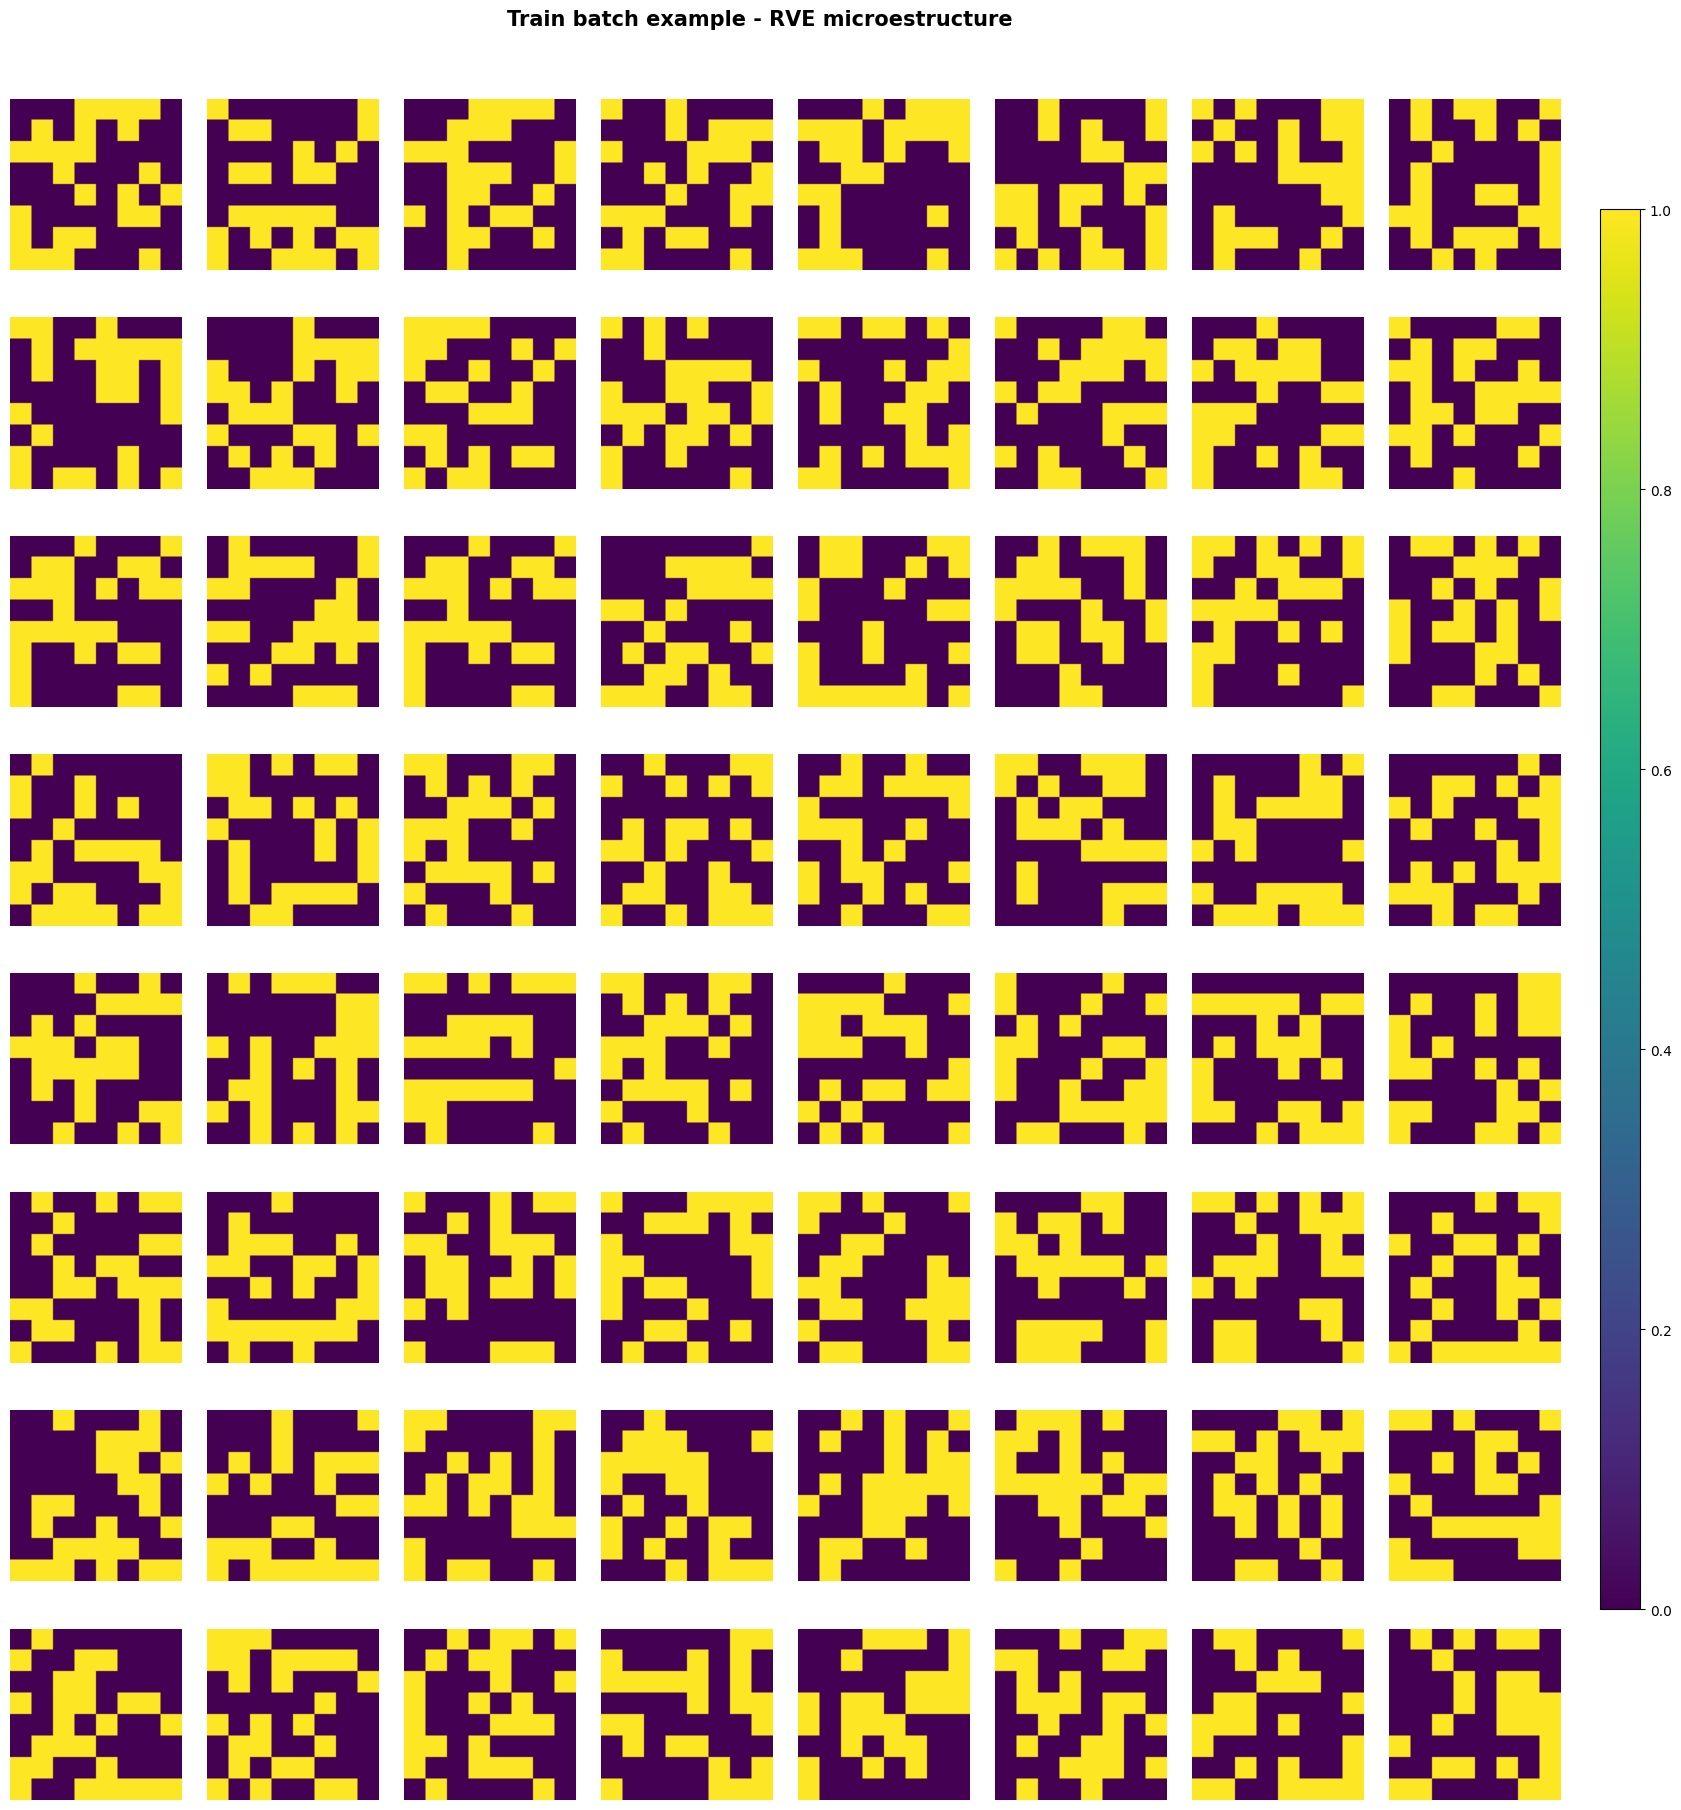

In [11]:
show_batch_channels(train_loader,
                    channel = 0,        # Material phase
                    title='Train batch example - RVE microestructure'
                 )

### 4. Model configuration

In [ ]:
# Build model base on HPO analyis.
# We based on trial 27.
cfg.best_params = {
    "n_modes": 16,
    "hidden_channels": 64,
    "n_layers": 4,
    "film_mlp_layers": 2,
    "film_mlp_neurons": 128
}

model = DualEncoderFNO(
    in_channels         = in_channels,
    out_channels        = out_channels,
    n_macro             = n_macro,
    **cfg.best_params,
    use_positional_grid = True,
    film_per_layer      = True
    ).to(cfg.device)

model.save_config("../checkpoints/rve2_fno_config.pth")

Saved configuration at ../checkpoints/rve2_fno_config.pth


In [13]:
n_params = model.count_parameters()
print(f"\nOur model has {n_params} parameters.")


Our model has 4836291 parameters.


### 5. Training

In [ ]:
cfg.epochs = 200
cfg.lr = 1e-3
cfg.weight_decay = 1e-4
cfg.max_grad_norm = 1.0
cfg.patience = cfg.epochs + 1
cfg.lr_min = 1e-6

l2loss = LpLoss(d=2, p=2, reduction='mean')     # L2 loss for function values
h1loss = H1Loss(d=2, reduction='mean')
msloss = nn.MSELoss()

def combined_loss(pred, target):
    return 0.7 * l2loss(pred, target) + 0.3 * h1loss(pred, target)

trainer = Trainer(
    model=model,
    loss_fun=h1loss,
    val_metrics={'l2': l2loss},
    wandb_log=False,
    device=cfg.device,
    save_dir="../checkpoints",
    min_delta=1e-7,
    max_grad_norm=cfg.max_grad_norm,
    verbose=True
)

In [15]:
optimizer = torch.optim.AdamW(
  model.parameters(),
  lr = cfg.lr,
  weight_decay = cfg.weight_decay,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,          # Reduce LR to the half when it plateaus
    patience=5,          # Wait 5 epochs without improvement before reducing
    threshold=1e-4,      # Minimum improvement to not consider stagnation
    min_lr=cfg.lr_min,   # Do not decrease LR below 1e-6
)

history = trainer.fit(
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=cfg.epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    patience=cfg.patience,
    model_name="rve2_fno_params.pth",
    verbose=True
)

DualEncoderFNO Training: 200 epochs



   Best model saved (Epoch 1)
Epoch   1/200 | Train Loss: 0.548819 | Val Loss: 0.452758 | Val L2: 0.546395 | LR: 1.00e-03


   Best model saved (Epoch 2)
Epoch   2/200 | Train Loss: 0.324944 | Val Loss: 0.382959 | Val L2: 0.498729 | LR: 1.00e-03


   Best model saved (Epoch 3)
Epoch   3/200 | Train Loss: 0.264895 | Val Loss: 0.350818 | Val L2: 0.468440 | LR: 1.00e-03


   Best model saved (Epoch 4)
Epoch   4/200 | Train Loss: 0.233366 | Val Loss: 0.321221 | Val L2: 0.436637 | LR: 1.00e-03


...

Epoch 196/200 | Train Loss: 0.066698 | Val Loss: 0.198485 | Val L2: 0.166783 | LR: 1.00e-06


Epoch 197/200 | Train Loss: 0.066695 | Val Loss: 0.198465 | Val L2: 0.166796 | LR: 1.00e-06


Epoch 198/200 | Train Loss: 0.066695 | Val Loss: 0.198454 | Val L2: 0.166748 | LR: 1.00e-06


Epoch 199/200 | Train Loss: 0.066693 | Val Loss: 0.198497 | Val L2: 0.166797 | LR: 1.00e-06


Epoch 200/200 | Train Loss: 0.066692 | Val Loss: 0.198488 | Val L2: 0.166773 | LR: 1.00e-06

 Training finished. Best epoch: 184 (Loss = 0.198454)


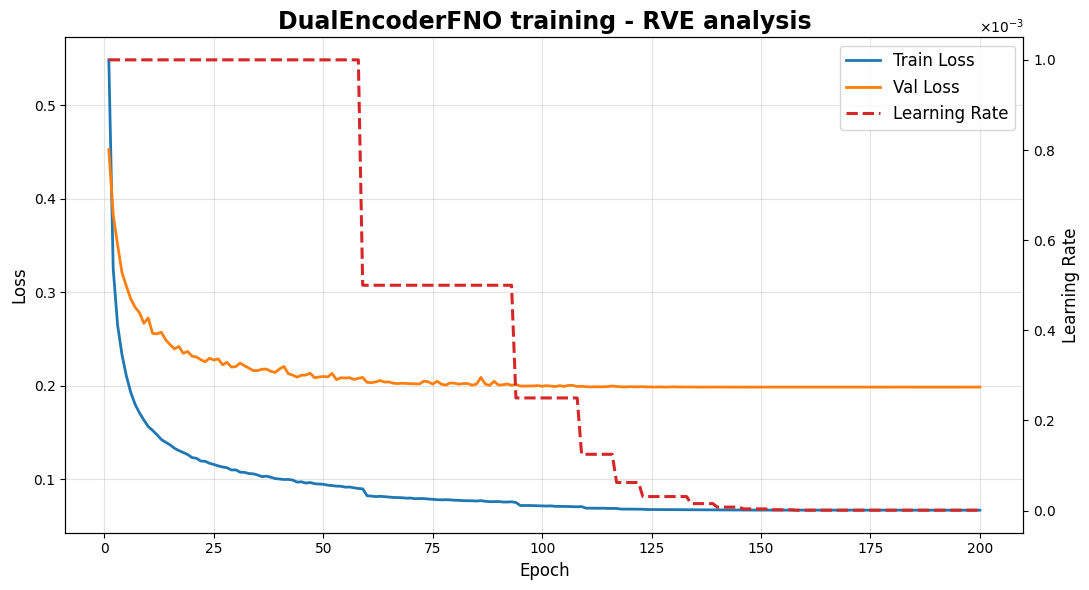

In [16]:
trainer.plot_history(title="DualEncoderFNO training - RVE analysis")

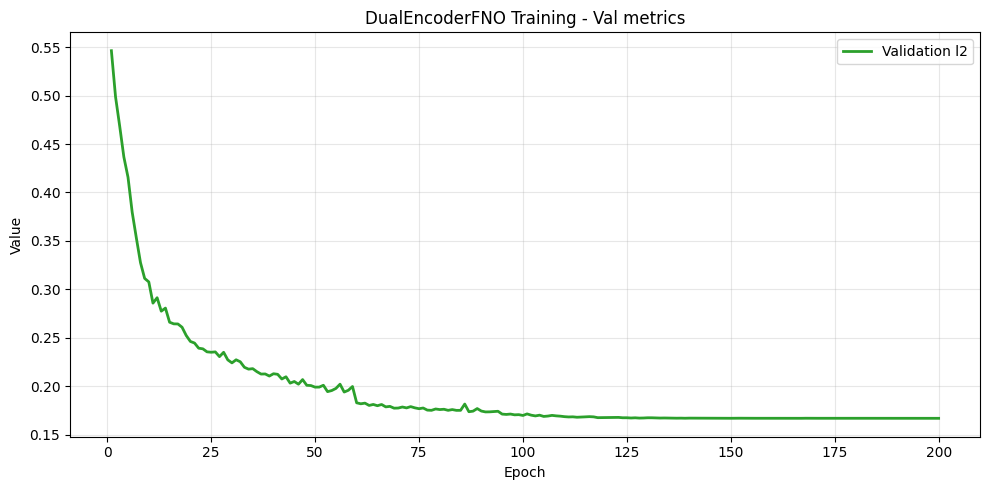

In [17]:
trainer.plot_metric(metric_name='l2')